## 0. import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 1. 데이터 준비

In [2]:
RANDOM_STATE = 203

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

def to_grade(q):
    if q <= 4:
        return 'low'
    elif q <= 6:
        return 'medium'
    else:
        return 'high'

df['grade'] = df['quality'].apply(to_grade)

X = df.drop(columns=['quality', 'grade'])
y = df['grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

## 2. n_estimators 비교

In [3]:
n_estimators_list = [1, 5, 10, 30, 50, 100, 200]
train_acc_list = []
test_acc_list = []

for n in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_features='sqrt',
        random_state=RANDOM_STATE
    )

    rf.fit(X_train, y_train)

    train_acc = rf.score(X_train, y_train)
    test_acc = rf.score(X_test, y_test)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print(f"estimators {n} train_acc : {train_acc:.3f}")
    print(f"estimators {n} test_acc : {test_acc:.3f}")


estimators 1 train_acc : 0.934
estimators 1 test_acc : 0.803
estimators 5 train_acc : 0.973
estimators 5 test_acc : 0.834
estimators 10 train_acc : 0.990
estimators 10 test_acc : 0.859
estimators 30 train_acc : 0.999
estimators 30 test_acc : 0.869
estimators 50 train_acc : 1.000
estimators 50 test_acc : 0.863
estimators 100 train_acc : 1.000
estimators 100 test_acc : 0.853
estimators 200 train_acc : 1.000
estimators 200 test_acc : 0.859


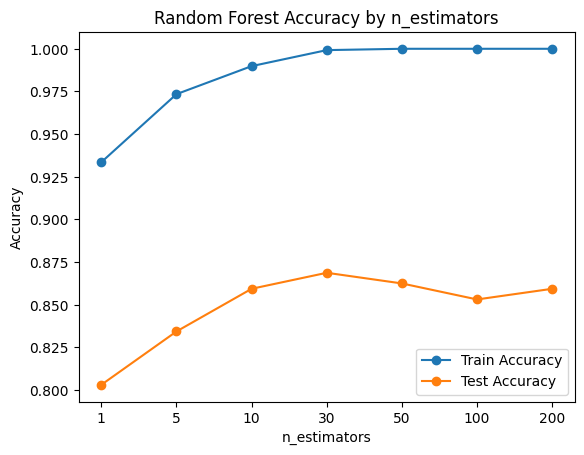

In [4]:
x = range(len(n_estimators_list))

plt.plot(x, train_acc_list, marker='o', label='Train Accuracy')
plt.plot(x, test_acc_list, marker='o', label='Test Accuracy')

plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by n_estimators')

plt.xticks(x, n_estimators_list)

plt.legend()
plt.show()

## 3. max_features 비교

In [5]:
max_features_list = ['sqrt', 5, None]
train_acc_list = []
test_acc_list = []


for mf in max_features_list:
    rf = RandomForestClassifier(
        n_estimators=30,
        max_features=mf,
        random_state=RANDOM_STATE
    )

    rf.fit(X_train, y_train)

    train_acc = rf.score(X_train, y_train)
    test_acc = rf.score(X_test, y_test)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print(f"max feature [{mf}] train_acc : {train_acc:.3f}")
    print(f"max feature [{mf}] test_acc : {test_acc:.3f}")

max feature [sqrt] train_acc : 0.999
max feature [sqrt] test_acc : 0.869
max feature [5] train_acc : 0.999
max feature [5] test_acc : 0.859
max feature [None] train_acc : 1.000
max feature [None] test_acc : 0.863


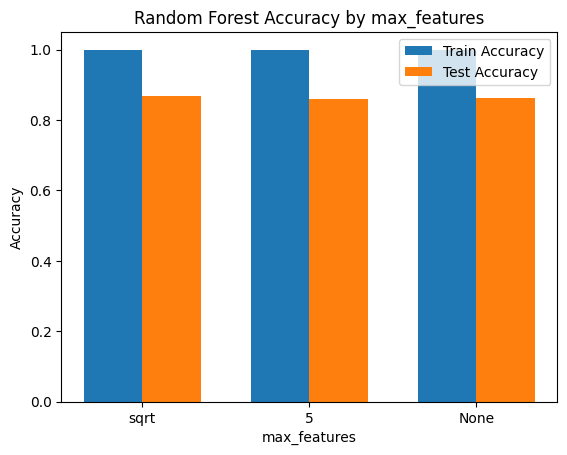

In [6]:
max_features_list = ['sqrt', 5, "None"]

x = np.arange(len(max_features_list))
width = 0.35

plt.bar(x - width / 2, train_acc_list, width, label='Train Accuracy')
plt.bar(x + width / 2, test_acc_list, width, label='Test Accuracy')

plt.xlabel('max_features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by max_features')

plt.xticks(x, max_features_list)

plt.legend()
plt.show()